In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# train test split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# accuracy score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler


In [9]:
df = pd.read_csv('/Users/mohddanish/Desktop/Machine_Learning/MachineLearning/Feature_Engineering/FeatureTransformation/Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [10]:
X_train, X_test, y_train, y_test = train_test_split(df[['Age', 'EstimatedSalary']], df['Purchased'], test_size=0.2, random_state=42)

In [11]:
normalizer = MinMaxScaler()
X_train_normalized = normalizer.fit_transform(X_train)
X_test_normalized = normalizer.transform(X_test)

In [12]:
# convert to DataFrame with SAME index
X_train_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns, index=X_train.index)
X_test_normalized = pd.DataFrame(X_test_normalized, columns=X_test.columns, index=X_test.index)


In [13]:
# combine both
X_all_normalized = pd.concat([X_train_normalized, X_test_normalized]).sort_index()

In [17]:
X_all_normalized.head()

,Age,EstimatedSalary
0,0.023810,0.029630
1,0.404762,0.037037
2,0.190476,0.207407
3,0.214286,0.311111
4,0.023810,0.451852


In [14]:
df[['Age_normalized', 'EstimatedSalary_normalized']] = X_all_normalized

In [15]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased,Age_normalized,EstimatedSalary_normalized
0,15624510,Male,19,19000,0,0.023810,0.029630
1,15810944,Male,35,20000,0,0.404762,0.037037
2,15668575,Female,26,43000,0,0.190476,0.207407
3,15603246,Female,27,57000,0,0.214286,0.311111
4,15804002,Male,19,76000,0,0.023810,0.451852


Before Scaling the graph and after Scaling the graph

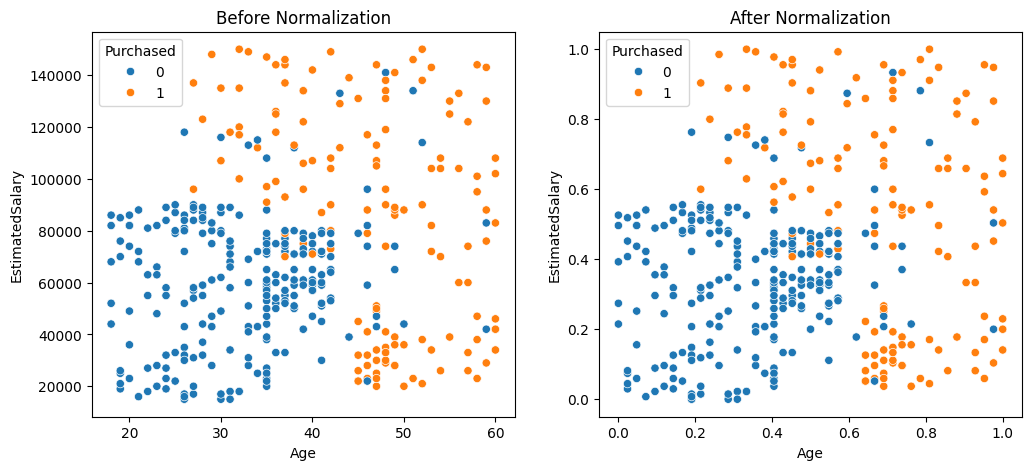

In [18]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x='Age', y='EstimatedSalary', hue='Purchased', data=df)
plt.title('Before Normalization')
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Age_normalized', y='EstimatedSalary_normalized', hue='Purchased', data=df)    
plt.title('After Normalization')
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')    
plt.show()